# Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import re

# Load dataset

In [5]:
df = pd.read_csv("total_data.csv")

print("Dataset shape:", df.shape)
print("\nFirst rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

Dataset shape: (24806, 3)

First rows:
   STT                                           Contents            Labels
0    1  trong các trường hợp khác, hiệu trưởng sẽ xác ...  Quy_Che_Quy_Dinh
1    2  để được phép theo học hai chương trình song so...  Quy_Che_Quy_Dinh
2    3  thời gian đặc biệt không dẫn đến việc nhân đôi...  Quy_Che_Quy_Dinh
3    4  theo quy định của trường, 1 tín chỉ sẽ tương đ...  Quy_Che_Quy_Dinh
4    5  lý thuyết và thực nghiệm diễn ra vào buổi sáng...  Quy_Che_Quy_Dinh

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24806 entries, 0 to 24805
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   STT       24806 non-null  int64 
 1   Contents  24806 non-null  object
 2   Labels    24806 non-null  object
dtypes: int64(1), object(2)
memory usage: 581.5+ KB
None


In [6]:
print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna(subset=["Contents"])



Missing values:
STT         0
Contents    0
Labels      0
dtype: int64


In [7]:
duplicates = df.duplicated(subset=["Contents"]).sum()
print("\nDuplicate rows:", duplicates)

df = df.drop_duplicates(subset=["Contents"])


Duplicate rows: 30



Label distribution:
Labels
Quy_Che_Quy_Dinh        5113
Thong_Tin_Tuyen_Sinh    5101
Thong_tin_khoa          5075
Thong_Tin_Trung_Tam     5024
Thong_Tin_Truong        4463
Name: count, dtype: int64


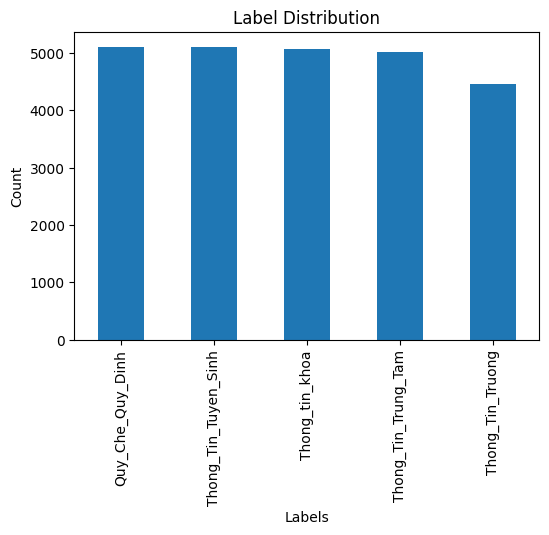

In [8]:
print("\nLabel distribution:")
print(df["Labels"].value_counts())

plt.figure(figsize=(6,4))
df["Labels"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.show()


# Sentence length analysis


Sentence length statistics:
count    24776.000000
mean        30.267033
std         15.908831
min          3.000000
25%         21.000000
50%         28.000000
75%         36.000000
max        765.000000
Name: length, dtype: float64


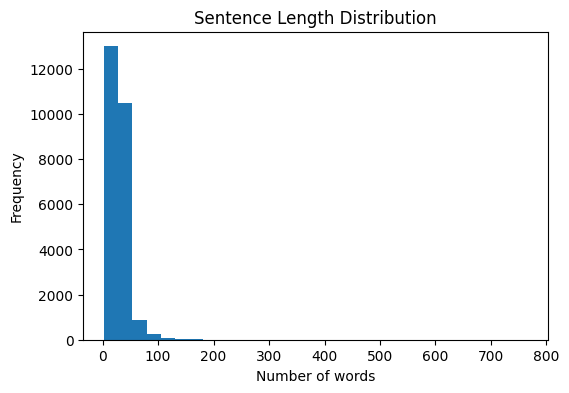

In [9]:
df["length"] = df["Contents"].apply(lambda x: len(str(x).split()))

print("\nSentence length statistics:")
print(df["length"].describe())

plt.figure(figsize=(6,4))
plt.hist(df["length"], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()


# Balance check

In [10]:
print("\nLabel distribution:")
print(df["Labels"].value_counts())


Label distribution:
Labels
Quy_Che_Quy_Dinh        5113
Thong_Tin_Tuyen_Sinh    5101
Thong_tin_khoa          5075
Thong_Tin_Trung_Tam     5024
Thong_Tin_Truong        4463
Name: count, dtype: int64


In [11]:
text = " ".join(df["Contents"].astype(str)).lower()

words = re.findall(r'\b\w+\b', text)

word_freq = Counter(words)

print("\nTop 20 most common words:")
print(word_freq.most_common(20))


Top 20 most common words:
[('học', 22185), ('và', 15008), ('công', 14082), ('nghiệp', 10979), ('sinh', 10320), ('viên', 10051), ('năm', 9825), ('các', 9376), ('trường', 8946), ('đại', 8751), ('của', 8685), ('được', 7548), ('trong', 7373), ('cho', 7256), ('có', 6453), ('tại', 6136), ('đã', 5981), ('tp', 5195), ('trung', 5054), ('vào', 5019)]


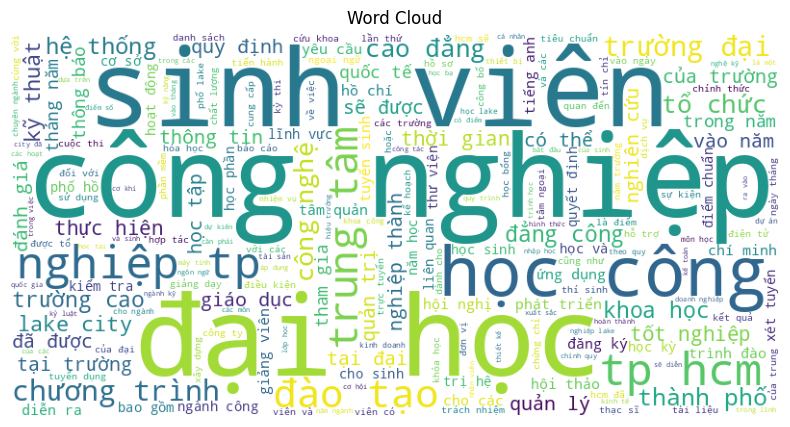

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [37]:
df

,STT,Contents,Labels,length,clean_text
0,1,một tín chỉ được tính tương đương 50 giờ học t...,Quy_Che_Quy_Dinh,28,một tín chỉ được tính tương đương 50 giờ học t...
1,2,"theo quy định của trường, 1 tín chỉ sẽ tương đ...",Quy_Che_Quy_Dinh,19,theo quy định của trường 1 tín chỉ sẽ tương đư...
2,3,"đối với các môn thực hành hoặc thí nghiệm, một...",Quy_Che_Quy_Dinh,18,đối với các môn thực hành hoặc thí nghiệm một ...
3,4,cho em hỏi 1 tín chỉ thực hành tương đương với...,Quy_Che_Quy_Dinh,18,cho em hỏi 1 tín chỉ thực hành tương đương với...
4,5,1 tín chỉ là bao nhiêu tiết lý thuyết vậy mọi ...,Quy_Che_Quy_Dinh,13,1 tín chỉ là bao nhiêu tiết lý thuyết vậy mọi ...
...,...,...,...,...,...
9962,9963,Trong khoảng thời gian 01 tháng chờ đợi các th...,Thong_Tin_Tuyen_Sinh,44,trong khoảng thời gian 01 tháng chờ đợi các th...
9963,9964,Sinh viên tốt nghiệp từ các trường cao đẳng ng...,Thong_Tin_Tuyen_Sinh,42,sinh viên tốt nghiệp từ các trường cao đẳng ng...
9964,9965,Trường cao đẳng công nghiệp của thành phố tại ...,Thong_Tin_Tuyen_Sinh,55,trường cao đẳng công nghiệp của thành phố tại ...
9965,9966,"Ngoài IELTS và VST, các chứng chỉ ngôn ngữ quố...",Thong_Tin_Tuyen_Sinh,48,ngoài ielts và vst các chứng chỉ ngôn ngữ quốc...


In [ ]:
df.to_csv('cleaned_data.csv', index=False, encoding='utf-8-sig')

: 